# Notebook 4: Extra Credit - Optimización Financiera del Negocio (Thresholds y Costos)

## 🚀 FinanceGuard Anti-Churn Initiative: Traduciendo Predicciones a Rentabilidad

Este notebook representa la fase de **"Extra Credit"** y el cierre del proyecto FinanceGuard Anti-Churn. Después de haber establecido un `baseline` (Notebook 1), maximizado el poder predictivo con modelos avanzados y `ensembles` (Notebook 2), y descubierto perfiles de clientes con `clustering` (Notebook 3), ahora nos enfocamos en el aspecto más crítico para el negocio: **cómo las predicciones del modelo se traducen directamente en ganancias o pérdidas financieras**.

El objetivo de este avance es ir más allá de las métricas puramente estadísticas de rendimiento del modelo y optimizar el punto de corte (`threshold`) de la probabilidad de churn, considerando los **costos y beneficios asimétricos** que cada tipo de error o acierto del modelo tiene para FinanceGuard.

### Objetivos Detallados de Este Notebook:
1.  **Carga y Preprocesamiento de Datos:** Reutilizar el pipeline de preprocesamiento para garantizar la consistencia.
2.  **Carga del Mejor Modelo Supervisado:** Re-entrenar el `XGBoost Optimizado` del Notebook 2 (o cargar si se guardó) para obtener sus probabilidades de predicción.
3.  **Definición de Métricas de Negocio (Costos y Beneficios):** Establecer los valores monetarios asociados a cada resultado de la matriz de confusión (`TP`, `TN`, `FP`, `FN`).
4.  **Optimización de `Threshold` Personalizada:** Iterar sobre un rango de umbrales de probabilidad para identificar el punto de corte que maximiza el beneficio (o minimiza el costo) total para el banco.
5.  **Visualización de la Curva de Beneficio:** Graficar el beneficio total en función del umbral para comunicar el punto óptimo.
6.  **Análisis de Matriz de Confusión con Costos Personalizados:** Comparar el impacto financiero de la decisión con el umbral por defecto (0.5) versus el umbral óptimo.
7.  **Conclusiones y Recomendaciones Estratégicas:** Sintetizar todos los hallazgos del proyecto y proponer una estrategia de implementación clara y cuantificable.

## ⚙️ Carga de Librerías Esenciales
Importamos el conjunto completo de librerías Python necesarias para la manipulación de datos, visualización, preprocesamiento y la implementación del modelo XGBoost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, f1_score

import xgboost as xgb

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Ignorar advertencias menores
import warnings
warnings.filterwarnings('ignore')

## 📂 Carga y Preprocesamiento de Datos (Reutilización del Pipeline)
Reutilizamos el pipeline de preprocesamiento de los notebooks anteriores. Esto garantiza que los datos para este análisis final sean consistentes con los utilizados para entrenar nuestro mejor modelo supervisado. Es crucial que las transformaciones se apliquen de la misma manera.

In [2]:
# Cargar datos
df = pd.read_csv('../data/Churn_Modelling.csv')
# Eliminar columnas irrelevantes
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Definir X (features) y y (target)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# División estratificada Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Definir columnas numéricas y categóricas
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Pipeline de preprocesamiento (ColumnTransformer con StandardScaler y OneHotEncoder con drop='first')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

# Aplicar preprocesamiento
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de las características post-procesamiento
feature_names_processed = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

# Convertir a DataFrame
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names_processed, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names_processed, index=X_test.index)

print("Datos cargados y preprocesados con éxito.")
print(f"Dimensiones del set de entrenamiento: {X_train_df.shape}")
print(f"Dimensiones del set de prueba: {X_test_df.shape}")

Datos cargados y preprocesados con éxito.
Dimensiones del set de entrenamiento: (8000, 11)
Dimensiones del set de prueba: (2000, 11)


## 🤖 Carga o Re-entrenamiento del Mejor Modelo Supervisado (XGBoost Optimizado)

Del Notebook 2, identificamos el `XGBoost Optimizado` (obtenido a través de Grid Search) como uno de los modelos con mejor rendimiento. Para este avance, lo re-entrenaremos con los mejores parámetros encontrados para garantizar la reproducibilidad y obtener las probabilidades necesarias para la optimización del `threshold`.

**Nota:** En un entorno de producción, el modelo ya estaría guardado (`joblib`, `pickle`) y simplemente se cargaría.

In [3]:
print("Re-entrenando el modelo XGBoost Optimizado...")

# Calculamos scale_pos_weight para manejar el desbalance de clases
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_val = neg_count / pos_count

# Mejores hiperparámetros obtenidos por GridSearchCV en el Notebook 2
best_xgb_params = {
    'n_estimators': 150,
    'learning_rate': 0.05,
    'max_depth': 7,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'gamma': 0,
    'objective': 'binary:logistic',
    'random_state': 42,
    'n_jobs': -1,
    'scale_pos_weight': scale_pos_weight_val
}

xgb_optimized_model = xgb.XGBClassifier(**best_xgb_params)
xgb_optimized_model.fit(X_train_df, y_train)

y_proba = xgb_optimized_model.predict_proba(X_test_df)[:, 1]

# Probabilidades out-of-fold sobre TRAIN: sirven para elegir el umbral sin mirar el set de prueba
from sklearn.model_selection import cross_val_predict
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_proba_oof = cross_val_predict(xgb.XGBClassifier(**best_xgb_params), X_train_df, y_train, cv=skf, method='predict_proba')[:, 1]

print("Modelo XGBoost Optimizado entrenado y probabilidades de prueba obtenidas.")

Re-entrenando el modelo XGBoost Optimizado...


Modelo XGBoost Optimizado entrenado y probabilidades de prueba obtenidas.


## 💰 Definición de Métricas de Negocio: Costos y Beneficios Asimétricos

El paso más importante para la optimización del `threshold` es traducir los resultados de la matriz de confusión en términos monetarios. FinanceGuard tiene una asimetría de costos crítica:

*   **`FN` (Falso Negativo - Error Tipo II):** El modelo predice que el cliente NO hará churn, pero SÍ lo hace. Esto resulta en la **pérdida del valor de vida del cliente (LTV)**.
    *   **Costo de FN:** \$500 (valor de vida del cliente perdido).
*   **`FP` (Falso Positivo - Error Tipo I):** El modelo predice que el cliente SÍ hará churn, pero NO lo hace. Esto resulta en un **costo de intervención de retención innecesaria** (ej. un bono o un gestor de cuenta dedicado).
    *   **Costo de FP:** \$50 (costo del incentivo o campaña de retención).
*   **`TP` (Verdadero Positivo):** El modelo predice correctamente que el cliente SÍ hará churn, y el banco interviene para retenerlo. Esto **evita la pérdida de LTV** pero incurre en el costo de retención.
    *   **Beneficio de TP:** \$500 (LTV salvado) - \$50 (costo de retención) = +\$450.
*   **`TN` (Verdadero Negativo):** El modelo predice correctamente que el cliente NO hará churn, y NO lo hace. El banco no hace nada.
    *   **Beneficio/Costo de TN:** \$0 (sin acción, sin costo/beneficio directo en este cálculo, ya que son clientes estables que no requieren intervención).

Estos valores guiarán nuestra búsqueda del umbral óptimo.

In [4]:
COST_FN = 500  # Costo por Falso Negativo (cliente que se va y no se predijo)
COST_FP = 50   # Costo por Falso Positivo (cliente que no se va pero se le ofrece retención)
PROFIT_TP = 450 # Beneficio por Verdadero Positivo (cliente que se iba, se predijo, se retuvo: 500 - 50)
PROFIT_TN = 0   # Beneficio por Verdadero Negativo (cliente que no se va, no se predijo)

print(f"Costos y Beneficios definidos: FN={COST_FN}, FP={COST_FP}, TP={PROFIT_TP}, TN={PROFIT_TN}")

Costos y Beneficios definidos: FN=500, FP=50, TP=450, TN=0


## 📈 Optimización del `Threshold` y Curva de Beneficio

Por defecto un clasificador usa un umbral de 0.5. Cuando los costos son asimétricos (perder un cliente cuesta 10 veces más que una campaña de retención), ese umbral rara vez maximiza el beneficio.

**Metodología (sin data leakage):**
1.  Se obtienen probabilidades **out-of-fold** sobre el set de entrenamiento con validación cruzada estratificada (5 folds).
2.  Se prueban 100 umbrales entre 0.01 y 0.99 y se elige el que maximiza el beneficio **en entrenamiento**.
3.  Ese umbral se aplica **una sola vez** al set de prueba para medir el beneficio real.


--- Resultados de la Optimización de Threshold ---
Umbral óptimo: 0.08
Beneficio máximo (validación cruzada en train, 8,000 clientes): $465,850.00
Beneficio en TEST con umbral 0.50 (por defecto): $55,550.00
Beneficio en TEST con umbral óptimo 0.08: $110,150.00


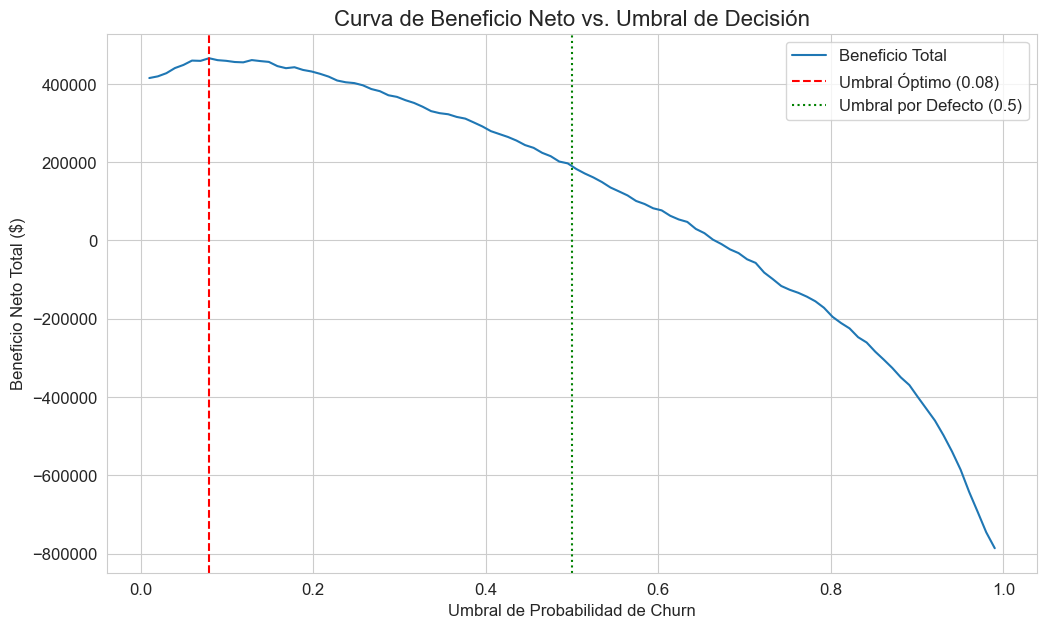

In [5]:
thresholds = np.linspace(0.01, 0.99, 100) # Probar 100 thresholds entre 0.01 y 0.99
profits = []
f1_scores_at_threshold = []

# El umbral se elige con las predicciones out-of-fold de TRAIN (evita sobreajustar el umbral al test)
for t in thresholds:
    y_pred_at_t = (y_proba_oof > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_at_t).ravel()

    current_profit = (tp * PROFIT_TP) + (tn * PROFIT_TN) - (fp * COST_FP) - (fn * COST_FN)
    profits.append(current_profit)
    
    # Calcular F1-score para el churn en este threshold
    f1_scores_at_threshold.append(f1_score(y_train, y_pred_at_t, pos_label=1, zero_division=0))

optimal_threshold_idx = np.argmax(profits)
optimal_threshold = thresholds[optimal_threshold_idx]
max_profit = profits[optimal_threshold_idx]

print(f"\n--- Resultados de la Optimización de Threshold ---")
print(f"Umbral óptimo: {optimal_threshold:.2f}")
print(f"Beneficio máximo (validación cruzada en train, 8,000 clientes): ${max_profit:,.2f}")

# Evaluación honesta: aplicamos ese umbral al set de prueba (2,000 clientes)
def profit_on_test(t):
    tn, fp, fn, tp = confusion_matrix(y_test, (y_proba > t).astype(int)).ravel()
    return (tp * PROFIT_TP) + (tn * PROFIT_TN) - (fp * COST_FP) - (fn * COST_FN)

print(f"Beneficio en TEST con umbral 0.50 (por defecto): ${profit_on_test(0.5):,.2f}")
print(f"Beneficio en TEST con umbral óptimo {optimal_threshold:.2f}: ${profit_on_test(optimal_threshold):,.2f}")

plt.figure(figsize=(12, 7))
plt.plot(thresholds, profits, label='Beneficio Total')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Umbral Óptimo ({optimal_threshold:.2f})')
plt.axvline(x=0.5, color='g', linestyle=':', label='Umbral por Defecto (0.5)')
plt.xlabel('Umbral de Probabilidad de Churn', fontsize=12)
plt.ylabel('Beneficio Neto Total ($)', fontsize=12)
plt.title('Curva de Beneficio Neto vs. Umbral de Decisión', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

### 💡 Insights de la Optimización del `Threshold`

*   **Umbral óptimo ≈ 0.08:** es muy bajo, y tiene sentido: con FN = \$500 y FP = \$50, intervenir conviene cuando la probabilidad de churn supera aproximadamente 50 / (50 + 500) ≈ 0.09. Además, `scale_pos_weight` hace que XGBoost produzca probabilidades infladas.
*   **Resultado en test (2,000 clientes):** el beneficio pasa de **\$55,550 (umbral 0.5) a \$110,150 (umbral 0.08)**, casi el doble.
*   **Matiz importante:** con este umbral se contacta a ~79% de los clientes. La estrategia es rentable **solo porque la campaña es barata ($50) frente al valor del cliente ($500)**. Si el costo de retención subiera o el presupuesto fuera limitado, el umbral óptimo subiría.

## 📊 Análisis de la Matriz de Confusión con Costos Personalizados

Para visualizar el impacto directo de esta optimización, mostraremos dos matrices de confusión:
1.  Con el `threshold` por defecto de 0.5.
2.  Con el `threshold` óptimo encontrado.

Además de los conteos de `TP`, `TN`, `FP`, `FN`, incluiremos el costo/beneficio monetario asociado a cada celda y el beneficio total para cada escenario.

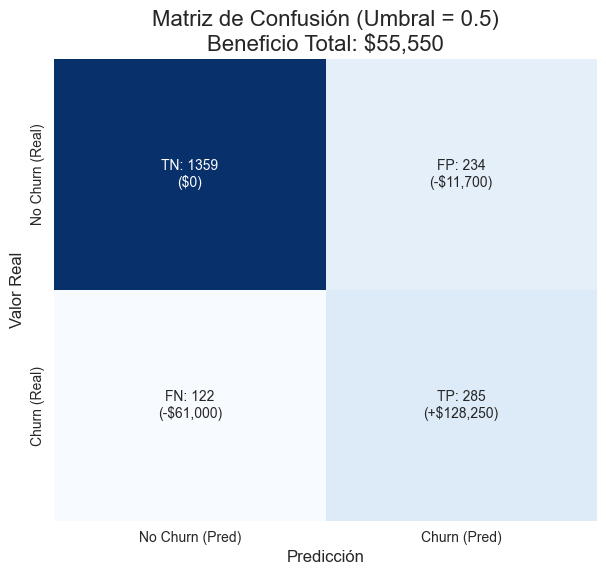

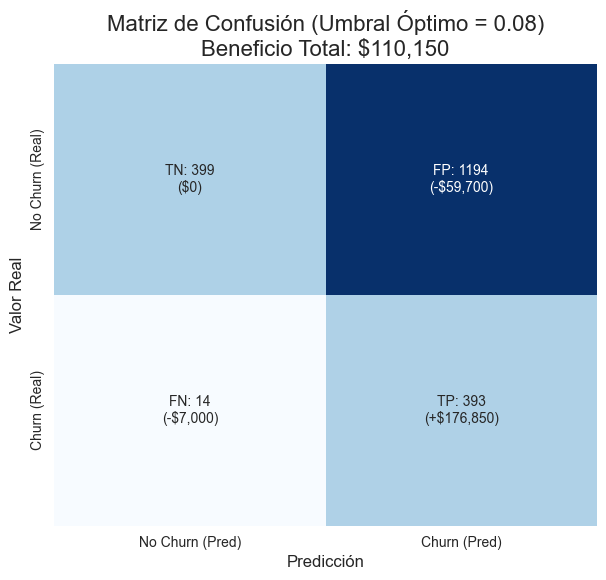

In [6]:
def plot_confusion_matrix_with_costs(y_true, y_proba, threshold, title, costs):
    y_pred = (y_proba > threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calcular beneficio/costo total para este umbral
    current_profit = (tp * costs['PROFIT_TP']) + \
                     (tn * costs['PROFIT_TN']) - \
                     (fp * costs['COST_FP']) - \
                     (fn * costs['COST_FN'])

    # Formatear la matriz con conteos y valores monetarios
    labels = np.asarray([[
        f'TN: {tn}\n(${tn * costs["PROFIT_TN"]:,.0f})',
        f'FP: {fp}\n(-${fp * costs["COST_FP"]:,.0f})'
    ],
    [
        f'FN: {fn}\n(-${fn * costs["COST_FN"]:,.0f})',
        f'TP: {tp}\n(+${tp * costs["PROFIT_TP"]:,.0f})'
    ]])
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['No Churn (Pred)', 'Churn (Pred)'],
                yticklabels=['No Churn (Real)', 'Churn (Real)'],
                annot_kws={"fontsize":10})
    plt.xlabel('Predicción', fontsize=12)
    plt.ylabel('Valor Real', fontsize=12)
    plt.title(f'{title}\nBeneficio Total: ${current_profit:,.0f}', fontsize=16)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.show()

business_costs = {
    'COST_FN': COST_FN,
    'COST_FP': COST_FP,
    'PROFIT_TP': PROFIT_TP,
    'PROFIT_TN': PROFIT_TN
}

# Matriz de confusión con threshold por defecto (0.5)
plot_confusion_matrix_with_costs(y_test, y_proba, 0.5, 'Matriz de Confusión (Umbral = 0.5)', business_costs)

# Matriz de confusión con threshold óptimo
plot_confusion_matrix_with_costs(y_test, y_proba, optimal_threshold, f'Matriz de Confusión (Umbral Óptimo = {optimal_threshold:.2f})', business_costs)

### 💡 Insights de la Matriz de Confusión con Costos (set de prueba)

| | Umbral 0.5 | Umbral 0.08 |
|---|---|---|
| Churners detectados (TP) | 285 de 407 (70%) | 393 de 407 (97%) |
| Churners no detectados (FN) | 122 | 14 |
| Falsas alarmas (FP) | 234 | 1,194 |
| **Beneficio neto** | **\$55,550** | **\$110,150** |

*   Bajar el umbral casi elimina los FN (los errores más caros) a cambio de muchas más falsas alarmas, que son baratas.
*   **Supuesto clave:** se asume que todo cliente contactado que iba a irse se retiene (beneficio de \$450). En la realidad la tasa de éxito de una campaña es menor, así que estos montos son un **límite superior** y deberían validarse con un A/B test.

## ✍️ Conclusiones Finales del Proyecto Integrador

### Resultados por avance

**1. Baseline (Regresión Logística):** AUC 0.78, Recall 0.70, F1 0.50. Principales drivers: Alemania (OR 2.28) y edad (OR 2.10) aumentan el riesgo; ser miembro activo (OR 0.60) y ser hombre (OR 0.59) lo reducen.

**2. Modelos avanzados:** los modelos de árboles superan al baseline (AUC 0.85–0.87, F1 ≈ 0.60–0.62). CatBoost obtuvo el mejor F1 (0.62) y el Stacking el mejor AUC (0.870), pero las diferencias entre modelos de boosting son pequeñas.

**3. No supervisado:** la estructura de clusters es débil (silueta ≈ 0.11), pero K-Means con K = 4 identificó un segmento de riesgo claro: **inactivos con saldo alto (32% de churn)**.

**4. Optimización financiera:** eligiendo el umbral con validación cruzada en train (0.08), el beneficio en test pasa de \$55,550 a \$110,150 frente al umbral por defecto, bajo el supuesto de retención exitosa en todos los contactos.

### Lecciones aprendidas
*   **Supervisado vs. no supervisado:** el supervisado predice *quién* se va; el no supervisado ayuda a entender *qué tipos* de clientes hay y a diseñar campañas.
*   **Evitar data leakage:** el set de prueba no debe usarse para early stopping ni para elegir el umbral.
*   **La métrica técnica no es la de negocio:** el umbral correcto depende de los costos, no de maximizar accuracy.

### Trabajo futuro
*   Explicabilidad por cliente con **SHAP**.
*   Recalibrar probabilidades (`CalibratedClassifierCV`).
*   Validar la tasa real de éxito de las campañas con **A/B testing** antes de fijar el umbral.
*   Desplegar el modelo como API (FastAPI) o dashboard (Streamlit).